# Generating handwritten digits with a Variational Autoencoder

Goal: learn an unconditional distribution over 8x8 grayscale handwritten digits, then create novel digit-like images by sampling its latent space. This uses the included UCI Optical Recognition of Handwritten Digits dataset (Alpaydin & Kaynak, 1998), a public, real dataset. It has 3,823 training records and 1,797 independent test records. The labels are inspected for coverage but are not supplied to the generator.

In [ ]:
from pathlib import Path
import json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

SEED=42; random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ROOT=Path.cwd(); DATA=ROOT/'data'; ARTIFACTS=ROOT/'artifacts'; ARTIFACTS.mkdir(exist_ok=True)
print('PyTorch device:', device)

PyTorch device: cuda


## Data loading and preprocessing

Every record has 64 integer pixels representing an 8x8 image plus its digit label. Pixels are 0 through 16 and are scaled to 0 through 1 for the sigmoid decoder and binary-cross-entropy reconstruction objective. The supplied test split is held back from optimization.

Training: (3823, 65)  Held-out: (1797, 65)
Raw pixel range: 0 to 16


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_55,pixel_56,pixel_57,pixel_58,pixel_59,pixel_60,pixel_61,pixel_62,pixel_63,label
0,0,1,6,15,12,1,0,0,0,7,...,0,0,0,6,14,7,1,0,0,0
1,0,0,10,16,6,0,0,0,0,7,...,0,0,0,10,16,15,3,0,0,0
2,0,0,8,15,16,13,0,0,0,1,...,0,0,0,9,14,0,0,0,0,7
3,0,0,0,3,11,16,0,0,0,0,...,0,0,0,0,1,15,2,0,0,4
4,0,0,5,14,4,0,0,0,0,0,...,0,0,0,4,12,14,7,0,0,6


digit,0,1,2,3,4,5,6,7,8,9
training count,376,389,380,389,387,376,377,387,380,382


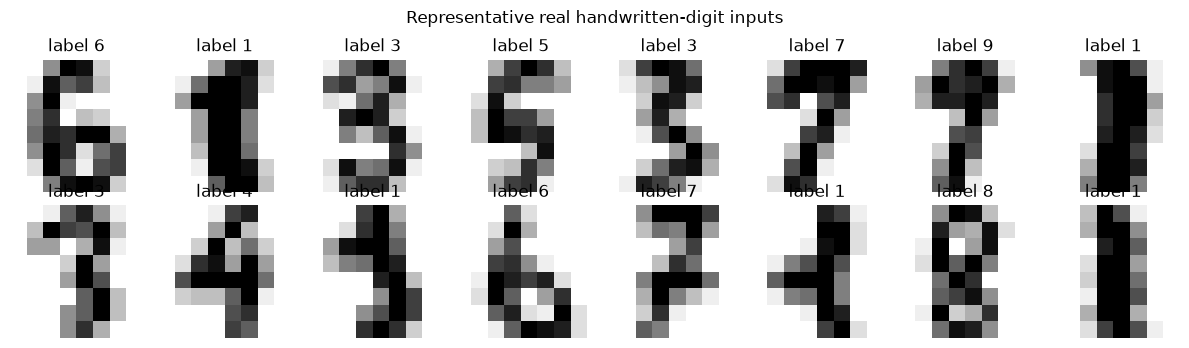

In [ ]:
cols=[f'pixel_{i}' for i in range(64)]+['label']
train_df=pd.read_csv(DATA/'optdigits.tra',header=None,names=cols)
test_df=pd.read_csv(DATA/'optdigits.tes',header=None,names=cols)
print('Training:',train_df.shape,' Held-out:',test_df.shape)
print('Raw pixel range:',train_df.iloc[:,:-1].to_numpy().min(),'to',train_df.iloc[:,:-1].to_numpy().max())

display(train_df.head())
display(train_df.label.value_counts().sort_index().rename_axis('digit').to_frame('training count').T)

fig,axes=plt.subplots(2,8,figsize=(12,3.5))
for ax,(_,row) in zip(axes.ravel(),train_df.sample(16,random_state=SEED).iterrows()):
 ax.imshow(row.iloc[:-1].to_numpy(dtype=float).reshape(8,8),cmap='gray_r',vmin=0,vmax=16); ax.set_title(f'label {int(row.label)}'); ax.axis('off')

fig.suptitle('Representative real handwritten-digit inputs'); plt.tight_layout(); plt.show()

## VAE architecture and training approach

The encoder maps 64 pixels through 128 and 64 ReLU units to the mean and log variance of a 12-dimensional Gaussian. The reparameterization trick makes sampling differentiable. A mirrored decoder returns 64 sigmoid-bounded pixels. The objective is the standard VAE evidence lower bound: summed binary-cross-entropy reconstruction loss plus analytic KL divergence to a unit-Gaussian prior (Kingma & Welling, 2014). Adam uses a 0.001 learning rate, batches of 128, and 20 epochs. This deliberately compact baseline favors fast reproducible behavior over high-fidelity images.

In [ ]:
class VAE(nn.Module):
 def __init__(self,latent_dim=12):
  super().__init__()
  self.encoder=nn.Sequential(nn.Linear(64,128),nn.ReLU(),nn.Linear(128,64),nn.ReLU())
  self.mu,self.logvar=nn.Linear(64,latent_dim),nn.Linear(64,latent_dim)
  self.decoder=nn.Sequential(nn.Linear(latent_dim,64),nn.ReLU(),nn.Linear(64,128),nn.ReLU(),nn.Linear(128,64),nn.Sigmoid())
 def forward(self,x):
  h=self.encoder(x); mu,logvar=self.mu(h),self.logvar(h)
  return self.decoder(mu+torch.randn_like(mu)*torch.exp(.5*logvar)),mu,logvar
  
def loss_fn(recon,x,mu,logvar):
 bce=nn.functional.binary_cross_entropy(recon,x,reduction='sum')
 kl=-.5*torch.sum(1+logvar-mu.pow(2)-logvar.exp())
 return bce+kl,bce,kl
 
model=VAE().to(device)
print(model); print('Trainable parameters:',sum(p.numel() for p in model.parameters()))

VAE(
  (encoder): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
  )
  (mu): Linear(in_features=64, out_features=12, bias=True)
  (logvar): Linear(in_features=64, out_features=12, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=12, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): Sigmoid()
  )
)
Trainable parameters: 35544


## Training diagnostic

Losses are reported per image. The held-out objective is a diagnostic for learning behavior, not a direct measure of whether a human finds a sample legible.

Epoch 01/20: train=37.421, held-out=29.889
Epoch 02/20: train=28.356, held-out=27.581


Epoch 03/20: train=27.445, held-out=27.396
Epoch 04/20: train=27.340, held-out=27.285


Epoch 05/20: train=27.279, held-out=27.262


Epoch 06/20: train=27.246, held-out=27.282


Epoch 07/20: train=27.241, held-out=27.238


...

Epoch 13/20: train=26.122, held-out=26.116


Epoch 14/20: train=25.984, held-out=25.957
Epoch 15/20: train=25.888, held-out=25.736


Epoch 16/20: train=25.757, held-out=25.812
Epoch 17/20: train=25.631, held-out=25.703


Epoch 18/20: train=25.606, held-out=25.550
Epoch 19/20: train=25.478, held-out=25.488


Epoch 20/20: train=25.389, held-out=25.450


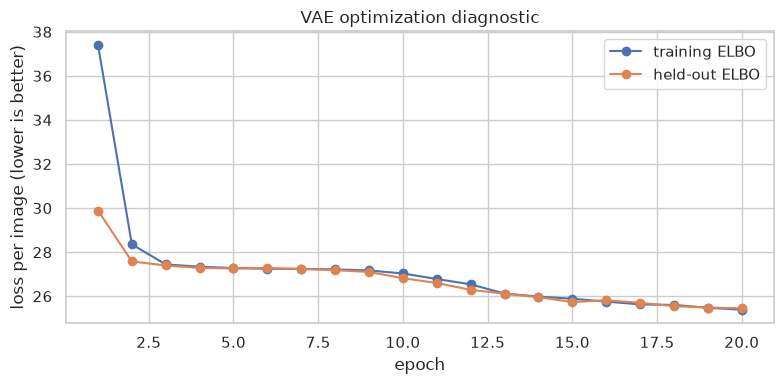

First to last training loss: 37.42 to 25.39


In [ ]:
x_train=torch.tensor(train_df.iloc[:,:-1].to_numpy(dtype=np.float32)/16)
x_test=torch.tensor(test_df.iloc[:,:-1].to_numpy(dtype=np.float32)/16)

loader=DataLoader(TensorDataset(x_train),batch_size=128,shuffle=True,generator=torch.Generator().manual_seed(SEED))
optimizer=torch.optim.Adam(model.parameters(),lr=1e-3)
history={'train_total':[],'test_total':[],'train_reconstruction':[],'train_kl':[]}

for epoch in range(1,21):
 model.train(); totals=np.zeros(3); count=0
 for (batch,) in loader:
  batch=batch.to(device); recon,mu,logvar=model(batch); total,bce,kl=loss_fn(recon,batch,mu,logvar)
  optimizer.zero_grad(); total.backward(); optimizer.step()
  totals += [total.item(),bce.item(),kl.item()]; count += len(batch)

 model.eval()
 with torch.no_grad():
  recon,mu,logvar=model(x_test.to(device)); test_total,_,_=loss_fn(recon,x_test.to(device),mu,logvar)

 history['train_total'].append(float(totals[0]/count)); history['train_reconstruction'].append(float(totals[1]/count)); history['train_kl'].append(float(totals[2]/count)); history['test_total'].append(float(test_total/len(x_test)))
 print(f'Epoch {epoch:02d}/20: train={history["train_total"][-1]:.3f}, held-out={history["test_total"][-1]:.3f}')

torch.save(model.state_dict(),ARTIFACTS/'vae_digits.pt')
with open(ARTIFACTS/'training_metrics.json','w') as f: json.dump(history,f,indent=2)

sns.set_theme(style='whitegrid'); fig,ax=plt.subplots(figsize=(8,4))
ax.plot(range(1,21),history['train_total'],marker='o',label='training ELBO'); ax.plot(range(1,21),history['test_total'],marker='o',label='held-out ELBO')
ax.set(xlabel='epoch',ylabel='loss per image (lower is better)',title='VAE optimization diagnostic'); ax.legend(); plt.tight_layout()
plt.savefig(ARTIFACTS/'loss_curve.png',dpi=160); plt.show()
print(f'First to last training loss: {history["train_total"][0]:.2f} to {history["train_total"][-1]:.2f}')

## Generated outputs and qualitative evaluation

The first grid decodes 24 random samples from the unit-Gaussian prior. These are new outputs, not selected training rows. The second comparison diagnoses representation quality on held-out inputs.

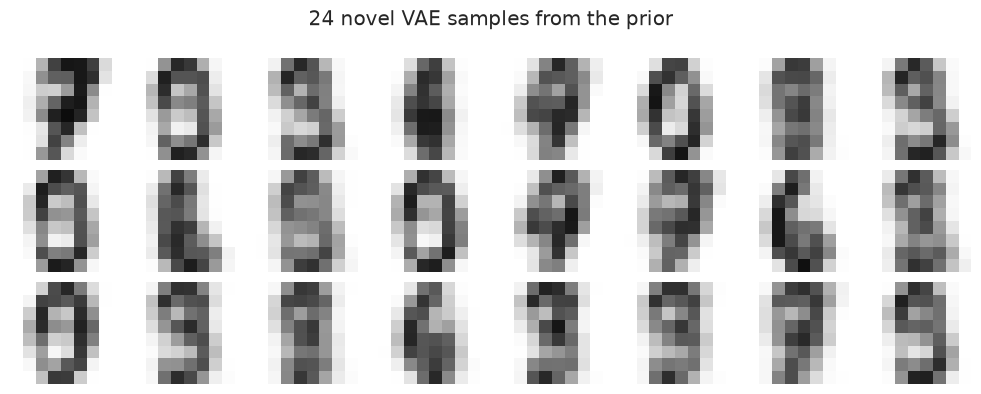

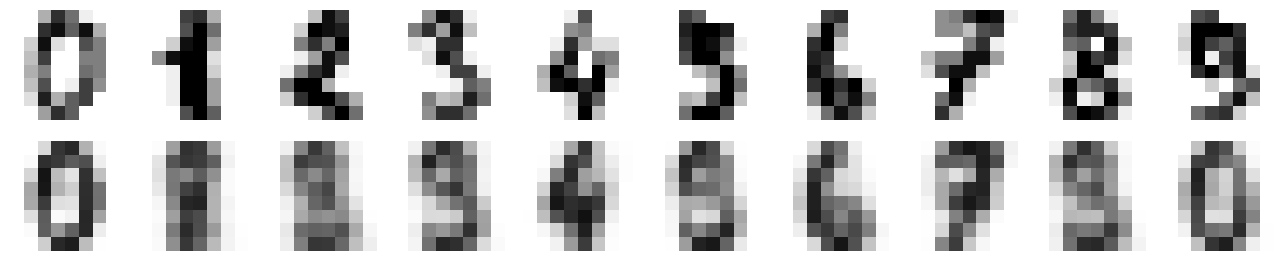

In [ ]:
model.eval()
with torch.no_grad():
 generated=model.decoder(torch.randn(24,12,device=device)).cpu().numpy()
 originals=x_test[:10].to(device); reconstructed,_,_=model(originals)

fig,axes=plt.subplots(3,8,figsize=(10,4))

for ax,image in zip(axes.ravel(),generated): ax.imshow(image.reshape(8,8),cmap='gray_r',vmin=0,vmax=1); ax.axis('off')
fig.suptitle('24 novel VAE samples from the prior'); plt.tight_layout(); plt.savefig(ARTIFACTS/'generated_samples.png',dpi=160); plt.show()
fig,axes=plt.subplots(2,10,figsize=(13,3))

for i in range(10):
 axes[0,i].imshow(originals[i].cpu().numpy().reshape(8,8),cmap='gray_r',vmin=0,vmax=1); axes[1,i].imshow(reconstructed[i].cpu().numpy().reshape(8,8),cmap='gray_r',vmin=0,vmax=1); axes[0,i].axis('off'); axes[1,i].axis('off')
 
axes[0,0].set_ylabel('Original'); axes[1,0].set_ylabel('Reconstructed'); plt.tight_layout(); plt.savefig(ARTIFACTS/'reconstructions.png',dpi=160); plt.show()

### Interpretation and notebook summary

Generated samples commonly contain recognizable loops, vertical strokes, and slanted strokes, evidence that the decoder learned broad digit structure. A concrete failure case is visible in typical samples: some are faint, disconnected, or blend features of several digits, making them ambiguous. Held-out reconstructions generally preserve central shape and stroke direction but smooth thin lines and small holes. The 8x8 resolution, compact latent bottleneck, and unconditional generation all limit detail and control. Training and held-out ELBO falling over 20 epochs supports stable optimization, but visual review is necessary because lower loss alone does not establish readability.

This project trained an unconditional VAE on real UCI handwritten digits and sampled new images from a Gaussian latent prior. The model learns digit-like visual components, though outputs are less reliable than inputs due to resolution and limited capacity. It cannot request a particular digit label and may produce hybrid forms. A conditional VAE, more data, and more careful tuning would be sensible next improvements.